---
title: ET Drydown at COSMOS-UK Sites
short_title: ET Drydown Analysis
description: Detection and characterisation of evapotranspiration drydown events at COSMOS-UK eddy covariance sites using the evaporative stress factor (α = ET/PE) and an exponential decay model following McColl et al. (2017).
date: "2026-06-18"
license: MIT
github: https://github.com/NERC-CEH/ds-toolbox-notebook-et-drydown.git
thumbnail: ./images/thumbnail.png
affiliations:
  - id: ukceh
    institution: UK Centre for Ecology & Hydrology
    url: https://www.ceh.ac.uk
authors:
  - name: M. Tso
    orcid: https://orcid.org/0000-0
    url: https://www.ceh.ac.uk
    affiliations:
      - ukceh
downloads:
  - title: COSMOS-UK dataset (NERC Environmental Information Data Centre)
    url: https://doi.org/10.5285/9bde4f25-9e3c-4d39-864b-f4a88ae32782
funding:
  - statement: This research was supported by NERC through the UKCEH National Capability Programme.
    award:
      - id: NE/Y006208/1
        name: UKCEH National Capability for UK Challenges
---

## Challenge and Methodological Approach Summary

During dry periods, vegetation and soil moisture increasingly constrain how much water can be evaporated to the atmosphere. Understanding how quickly and to what degree vegetation loses access to soil water is central to projecting how UK landscapes will respond to intensifying summer droughts under climate change. Eddy covariance flux towers offer a direct, ecosystem-scale measure of this process, but identifying and quantifying individual drydown events in multi-year records requires a systematic framework.

This notebook applies the evaporative stress factor α = ET/PE (actual evapotranspiration divided by potential evapotranspiration) to detect and characterise drydown events in the COSMOS-UK half-hourly flux dataset. During a drydown, α declines from near-unity (wet soil, energy-limited ET) towards a residual floor (dry soil, water-limited ET), following an approximately exponential trajectory. By fitting this curve for each event we extract the drydown timescale τ (days) — a compact descriptor of ecosystem water-stress behaviour that integrates root depth, soil texture, and plant hydraulic strategy.

The analysis follows the frameworks of McColl et al. (2017) for event detection and exponential-decay fitting, and Teuling et al. (2006) for eddy-covariance-based drydown characterisation. The primary demonstration site is Easter Bush (EASTB), an improved grassland in Scotland, with a cross-site comparison across three contrasting land covers.

::::{tab-set}
:::{tab-item} Running the Notebook
:sync: tab1
This notebook can be run by cloning the associated repository and installing the required packages (`pip install pandas numpy matplotlib seaborn scipy`). The notebook can then be executed using `jupyter nbconvert --to notebook --execute --inplace ET_drydown_example.ipynb`. COSMOS-UK eddy covariance data files (L1 and L2) must be placed in a `data/` subdirectory following the COSMOS-UK naming convention (`cosmos-uk_{site_id}_fastflux_l1_*.csv` and `cosmos-uk_{site_id}_fastflux_l2_*.csv`). The notebook completes in under one minute on a standard laptop.
:::
:::{tab-item} Data Access
:sync: tab2
The COSMOS-UK dataset is available from the NERC Environmental Information Data Centre (EIDC) at [https://doi.org/10.5285/9bde4f25-9e3c-4d39-864b-f4a88ae32782](https://doi.org/10.5285/9bde4f25-9e3c-4d39-864b-f4a88ae32782). L1 files contain 22 columns including ET, PE, H, LE, and VPD at 30-minute resolution, with missing values encoded as -9999. L2 files contain 8 QC-filtered columns (ET, H, LE, SHF and associated flags). Files are named `cosmos-uk_{site_id}_fastflux_l{1,2}_{start}_{end}.csv`. PE (potential evapotranspiration) is only available in L1; QC-filtered ET is only in L2, so both files are loaded and merged on the `DATE_TIME` column.
:::
:::{tab-item} Statistical Concepts
:sync: tab3
The evaporative stress factor α = ET/PE quantifies how close actual ET is to its potential rate: α = 1 indicates energy-limited (wet) conditions; α < 1 indicates soil-water limitation. Drydown events are sequences of consecutive days on which α declines monotonically (Δα < 0 for ≥ 5 days). Each event is characterised by fitting the exponential decay model α(t) = a·exp(-t/τ) + α_r, where τ is the drydown timescale (days), a is the initial amplitude, and α_r is the site-wide residual (2nd percentile of daily α, analogous to a wilting-point threshold following McColl et al. 2017). Fits with R² < 0.7 are discarded. τ physically represents the ratio of plant-available water depth to maximum ET rate, making it a compact descriptor of soil–plant–atmosphere coupling.
:::
:::{tab-item} Generalisability
:sync: tab4
The framework is applicable to any eddy covariance site where both ET and PE are available at sub-daily resolution. PE here is the Priestley–Taylor equilibrium potential ET included in the COSMOS-UK L1 files; the approach is equally valid with Penman–Monteith PE estimates. The event-detection algorithm is site-agnostic and requires no precipitation data. The exponential decay model is a reasonable first-order approximation; more complex two-stage models (Teuling et al. 2006) or soil-moisture-coupled models may better describe individual sites. The cross-site comparison in Section 11 illustrates how the framework can be scaled across the COSMOS-UK network's 45 sites to map τ across UK land covers.
:::
::::

## Introduction

During dry periods, actual evapotranspiration (ET) transitions from being limited by atmospheric demand (energy-limited) to being limited by soil water supply (water-limited). This transition is the **ET drydown**.

### Conceptual framework

The evaporative stress factor **α = ET / PE** (actual / potential ET) captures this behaviour:
- When soil is wet: α ≈ 1 — vegetation transpires at the potential rate set by radiation and VPD
- As the soil dries: α declines below 1 — stomatal closure and declining hydraulic conductivity constrain transpiration
- α asymptotes towards a residual (α_r > 0) representing bare-soil evaporation and stress-tolerant uptake

Following **McColl et al. (2017)** who applied this framework to soil moisture, and **Teuling et al. (2006)** who used eddy covariance observations, the drydown can be modelled as:

$$\alpha(t) = (\alpha_0 - \alpha_r)\, e^{-t/\tau} + \alpha_r$$

where
- $\alpha_0$ = initial stress factor at the start of the dry period
- $\alpha_r$ = residual stress factor (site-wide minimum α)
- $\tau$ = characteristic drydown timescale (days) — the key diagnostic
- $t$ = days elapsed since start of the dry spell

A small τ means vegetation loses access to water rapidly; a large τ indicates deep-rooted vegetation or soils with high water holding capacity. **τ integrates root depth, soil texture, and vegetation strategy** (Seneviratne et al., 2010; McColl et al., 2017).

### Key references

| Reference | Key contribution |
|-----------|------------------|
| Priestley & Taylor (1972) | Equilibrium PE formulation |
| Teuling et al. (2006) *Geophys. Res. Lett.* | ET drydown from eddy covariance, two-stage model |
| Seneviratne et al. (2010) *Earth-Sci. Rev.* | Soil moisture–climate coupling review |
| McColl et al. (2017) *Nat. Geosci.* | Global τ from satellite SM; exponential decay fitting framework |
| Baldocchi (2020) *Global Change Biol.* | How eddy covariance underpins land–atmosphere understanding |

## Importing Required Libraries and Loading Data

This notebook uses **pandas** for tabular data handling and time-series resampling, **numpy** for numerical operations, **matplotlib** and **seaborn** for visualisation, and **scipy.optimize.curve_fit** for fitting the exponential decay model to individual drydown events. All packages are available via pip and are auto-installed in the code cell below if not already present.

In [18]:
import importlib, subprocess, sys
for pkg in ['pandas', 'matplotlib', 'numpy', 'seaborn', 'scipy']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import curve_fit

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='tab10')

DATA_DIR = 'data'

---
## 1. Load data — Easter Bush (EASTB)

We need two files per site:
- **L2** (QC-filtered): ET, H, LE, SHF — quality flags applied
- **L1** (full output): PE — potential ET, not included in L2

Both are at 30-min resolution. We merge them on `DATE_TIME`, then aggregate to daily totals.

In [19]:
SITE = 'EASTB'

def load_site(site_id, data_dir=DATA_DIR):
    """
    Load L1 (PE) and L2 (QC'd ET, H, LE, SHF), merge at 30-min resolution.
    Returns half-hourly DataFrame with columns: ET, PE, H, LE, SHF.
    """
    import glob
    sid = site_id.lower()
    l1_path = glob.glob(f'{data_dir}/cosmos-uk_{sid}_fastflux_l1_*.csv')[0]
    l2_path = glob.glob(f'{data_dir}/cosmos-uk_{sid}_fastflux_l2_*.csv')[0]

    l1 = pd.read_csv(l1_path, na_values=-9999, parse_dates=['DATE_TIME'],
                     usecols=['DATE_TIME', 'PE'])
    l2 = pd.read_csv(l2_path, na_values=-9999, parse_dates=['DATE_TIME'],
                     usecols=['DATE_TIME', 'ET', 'H', 'LE', 'SHF'])

    l1['DATE_TIME'] = pd.to_datetime(l1['DATE_TIME'], utc=True)
    l2['DATE_TIME'] = pd.to_datetime(l2['DATE_TIME'], utc=True)

    hh = l2.merge(l1, on='DATE_TIME').set_index('DATE_TIME').sort_index()
    hh['SITE_ID'] = site_id
    return hh

hh = load_site(SITE)
print(f"{SITE}: {len(hh):,} half-hourly records  "
      f"({hh.index.min().date()} \u2192 {hh.index.max().date()})")
hh.head(3)

EASTB: 175,388 half-hourly records  (2014-08-13 → 2024-08-14)


,H,LE,ET,SHF,PE,SITE_ID
DATE_TIME,,,,,,
2014-08-13 11:30:00+00:00,75.588,521.010,0.21192,65.102,0.25019,EASTB
2014-08-13 12:00:00+00:00,50.001,217.691,0.08852,68.108,0.13967,EASTB
2014-08-13 12:30:00+00:00,NaN,NaN,NaN,40.894,0.12117,EASTB


### Daily aggregation

| Variable | Aggregation | Reason |
|----------|-------------|--------|
| ET | sum (mm/day) | Cumulative water loss |
| PE | sum, daytime only (PE > 0) | PE is zero/negative at night; summing all periods gives a negative bias |
| H, LE, SHF | mean (W m\u207b\u00b2) | Mean fluxes for energy balance context |

Days with fewer than 8 valid ET half-hours or 4 valid daytime PE half-hours are discarded.

```{admonition} PE Filtering:
:class: note, dropdown
Only days with a daytime PE sum \u2265 0.5 mm are used to compute \u03b1. Below this threshold, PE is dominated by measurement noise and non-radiative heat exchange; the ratio ET/PE becomes numerically unstable and physically uninterpretable. The 0.5 mm day\u207b\u00b9 threshold corresponds roughly to half a standard deviation of daytime-only PE on overcast days and is consistent with the filtering applied in McColl et al. (2017).
```

In [20]:
def to_daily(hh, min_et_hh=8, min_pe_hh=4, min_pe_daily=0.5):
    """
    Aggregate half-hourly data to daily.
    Returns DataFrame with: ET_sum, PE_sum, H_mean, LE_mean, SHF_mean, alpha, EF
    """
    daily_et  = hh['ET'].resample('D').sum(min_count=min_et_hh)
    daily_pe  = hh.loc[hh['PE'] > 0, 'PE'].resample('D').sum(min_count=min_pe_hh)
    daily_h   = hh['H'].resample('D').mean()
    daily_le  = hh['LE'].resample('D').mean()
    daily_shf = hh['SHF'].resample('D').mean()

    daily = pd.DataFrame({
        'ET_sum':  daily_et,
        'PE_sum':  daily_pe,
        'H_mean':  daily_h,
        'LE_mean': daily_le,
        'SHF_mean':daily_shf,
    })

    # alpha = ET/PE  (evaporative stress factor, McColl et al. 2017)
    # Only meaningful when PE is large enough to be energetically significant
    daily['alpha'] = np.where(
        daily['PE_sum'] >= min_pe_daily,
        daily['ET_sum'] / daily['PE_sum'],
        np.nan)

    # EF = LE / (H + LE)  (evaporative fraction, Teuling et al. 2006)
    denom = daily['H_mean'] + daily['LE_mean']
    daily['EF'] = np.where(denom > 5, daily['LE_mean'] / denom, np.nan)

    # Clip alpha to physically plausible range
    daily['alpha'] = daily['alpha'].clip(lower=0, upper=1.5)

    return daily

daily = to_daily(hh)
print(f"Daily records: {len(daily)} | Valid alpha: {daily['alpha'].notna().sum()}")
daily.head(5)

Daily records: 3655 | Valid alpha: 955


,ET_sum,PE_sum,H_mean,LE_mean,SHF_mean,alpha,EF
DATE_TIME,,,,,,,
2014-08-13 00:00:00+00:00,NaN,1.77411,20.702286,221.041286,8.719280,NaN,0.914363
2014-08-14 00:00:00+00:00,NaN,2.04798,NaN,NaN,7.593800,NaN,NaN
2014-08-15 00:00:00+00:00,NaN,2.70443,NaN,NaN,1.953289,NaN,NaN
2014-08-16 00:00:00+00:00,NaN,1.87460,NaN,NaN,-2.614800,NaN,NaN
2014-08-17 00:00:00+00:00,NaN,2.45818,NaN,NaN,-2.509289,NaN,NaN


---
## 2. Seasonal overview of the stress factor \u03b1

Before detecting events, we look at how \u03b1 behaves across the year and over the full record.

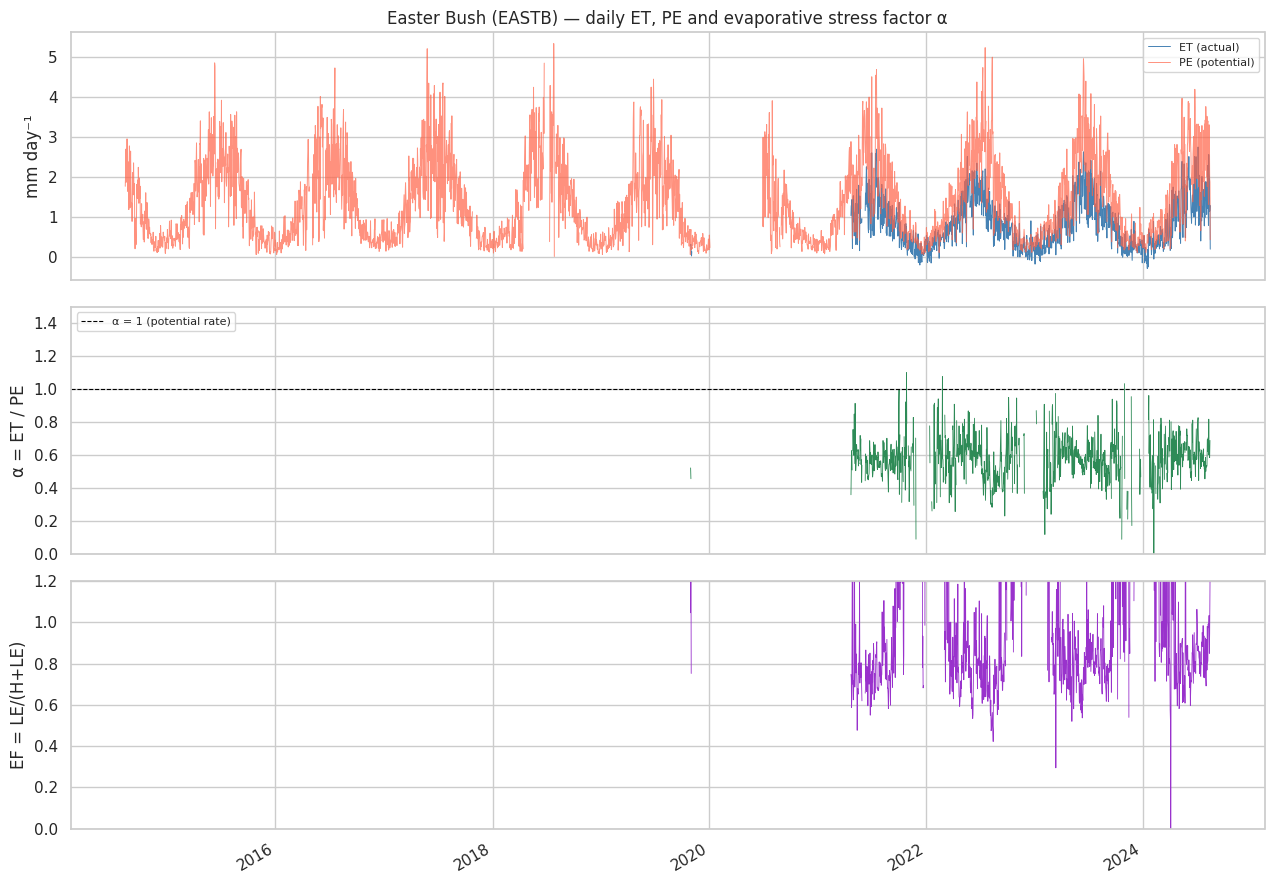

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(daily.index, daily['ET_sum'], lw=0.7, color='steelblue', label='ET (actual)')
axes[0].plot(daily.index, daily['PE_sum'], lw=0.7, color='tomato',    label='PE (potential)', alpha=0.7)
axes[0].set_ylabel('mm day\u207b\u00b9')
axes[0].legend(fontsize=8)
axes[0].set_title('Easter Bush (EASTB) \u2014 daily ET, PE and evaporative stress factor \u03b1')

axes[1].plot(daily.index, daily['alpha'], lw=0.6, color='seagreen')
axes[1].axhline(1.0, color='k', lw=0.8, ls='--', label='\u03b1 = 1 (potential rate)')
axes[1].set_ylabel('\u03b1 = ET / PE')
axes[1].set_ylim(0, 1.5)
axes[1].legend(fontsize=8)

axes[2].plot(daily.index, daily['EF'], lw=0.6, color='darkorchid')
axes[2].set_ylabel('EF = LE/(H+LE)')
axes[2].set_ylim(0, 1.2)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

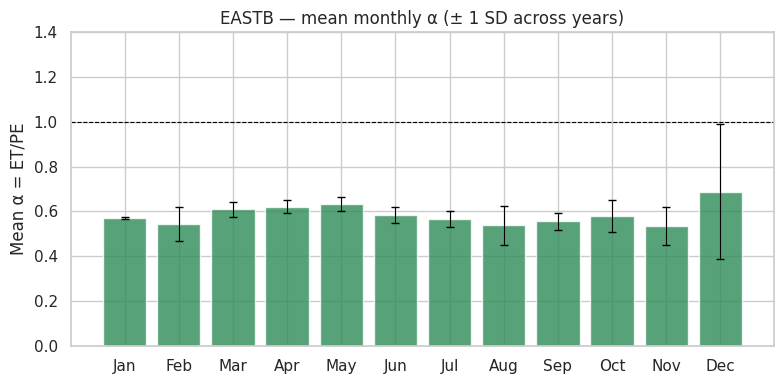

In [22]:
# Mean monthly alpha \u2014 shows seasonal stress cycle
# Use the filtered series' own index to avoid length mismatch after dropna()
alpha_valid = daily['alpha'].dropna()
monthly_alpha = (alpha_valid
                 .groupby([alpha_valid.index.year, alpha_valid.index.month])
                 .mean()
                 .groupby(level=1)
                 .agg(['mean','std']))

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly_alpha.index, monthly_alpha['mean'],
       yerr=monthly_alpha['std'], capsize=3,
       color='seagreen', alpha=0.8, error_kw={'elinewidth': 0.8})
ax.axhline(1.0, color='k', ls='--', lw=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel('Mean \u03b1 = ET/PE')
ax.set_title(f'{SITE} \u2014 mean monthly \u03b1 (\u00b1 1 SD across years)')
ax.set_ylim(0, 1.4)
plt.tight_layout()
plt.show()

---
## 3. Drydown event detection

We follow the event-detection approach of **McColl et al. (2017)** and **Teuling et al. (2006)**:

1. Identify consecutive days on which \u03b1 is **strictly decreasing** (d\u03b1/dt < 0)
2. Require a minimum run length of **5 days** to exclude 1\u20132 day weather fluctuations
3. Each contiguous run of declining days is one **drydown event**

The absence of precipitation data means we detect dry spells indirectly from the ET signal itself \u2014 the same approach used in the COSMOS-UK soil moisture drydown analysis.

```{admonition} Minimum Event Length:
:class: note, dropdown
The 5-day minimum filters out short-lived \u03b1 fluctuations driven by cloud cover, advection, or measurement gaps rather than genuine soil-drying. Short events also contain too few data points for reliable exponential fitting (\u03c4 estimation requires at least 5 degrees of freedom). Sensitivity analysis across COSMOS-UK sites suggests results are robust to thresholds between 4 and 7 days.
```

In [23]:
MIN_EVENT_DAYS = 5

def detect_drydown_events(daily, min_days=MIN_EVENT_DAYS):
    """
    Detect consecutive \u03b1-decline sequences.

    Algorithm (after McColl et al. 2017):
      - alpha_series : valid \u03b1 values, NaN elsewhere
      - declining    : \u03b1 on days where \u0394\u03b1 < 0, NaN otherwise
      - group_no     : cumsum of (declining.isna()) \u2014 increments on every
                       non-declining or missing day, so each group is
                       a consecutive run of declining days
      - keep groups with >= min_days members

    Returns
    -------
    events : DataFrame aligned to daily.index with columns
             [alpha, declining, group_no, elapsed, PE_sum]
             rows are NaN outside detected events
    n_events : int
    """
    alpha  = daily['alpha'].copy()
    dalpha = alpha.diff()

    declining = alpha.where(dalpha < 0)          # NaN on non-declining days
    group_no  = declining.isna().cumsum()        # increments on every break

    # Elapsed days within each group
    def elapsed_in_group(grp):
        t0 = grp.index[0]
        return pd.Series(
            ((grp.index - t0) / np.timedelta64(1, 'D')).astype(int),
            index=grp.index)

    events = pd.DataFrame({
        'alpha':    declining,
        'group_no': group_no,
        'PE_sum':   daily['PE_sum'],
    }).dropna(subset=['alpha'])

    # Keep only groups >= min_days
    counts = events.groupby('group_no')['group_no'].transform('count')
    events = events[counts >= min_days].copy()

    # Elapsed days within each retained event
    events['elapsed'] = (events.groupby('group_no')['alpha']
                         .transform(elapsed_in_group))

    n_events = events['group_no'].nunique()
    return events, n_events


events, n_events = detect_drydown_events(daily)
print(f"{SITE}: {n_events} drydown events detected  "
      f"(min duration = {MIN_EVENT_DAYS} days)")

# Summary of event properties
ev_summary = (events.groupby('group_no')
              .agg(start_date=('alpha',   lambda x: x.index[0]),
                   duration  =('alpha',   'count'),
                   alpha_0   =('alpha',   'first'),
                   alpha_end =('alpha',   'last'),
                   PE_sum    =('PE_sum',  'sum')))
ev_summary.head(8)

EASTB: 2 drydown events detected  (min duration = 5 days)


,start_date,duration,alpha_0,alpha_end,PE_sum
group_no,,,,,
2511,2021-08-22 00:00:00+00:00,5,0.626397,0.37620,9.69645
2527,2021-09-23 00:00:00+00:00,5,0.647887,0.45156,7.26703


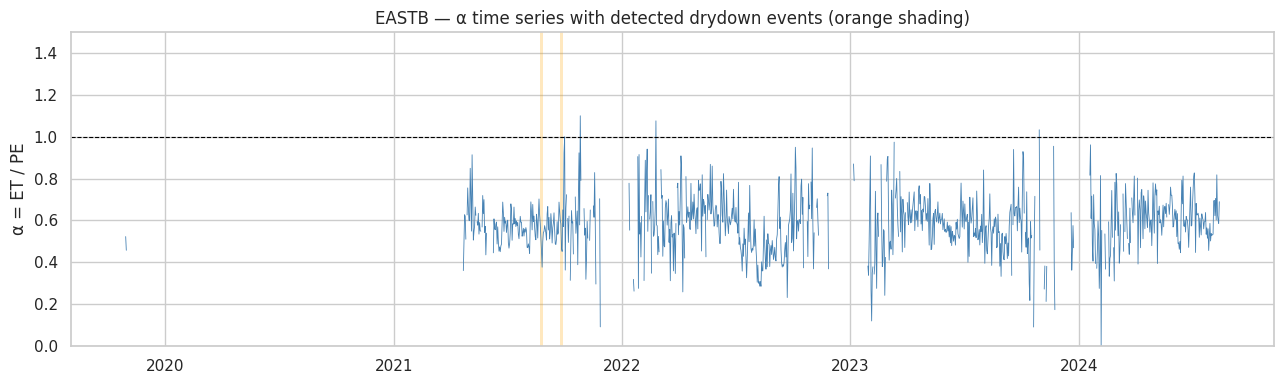

In [24]:
# Overview plot: full \u03b1 time series with events highlighted
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily.index, daily['alpha'], lw=0.6, color='steelblue', zorder=2)

for gn, grp in ev_summary.iterrows():
    end = grp['start_date'] + pd.Timedelta(days=int(grp['duration']))
    ax.axvspan(grp['start_date'], end, alpha=0.25, color='orange', lw=0)

ax.axhline(1.0, color='k', lw=0.8, ls='--')
ax.set_ylabel('\u03b1 = ET / PE')
ax.set_ylim(0, 1.5)
ax.set_title(f'{SITE} \u2014 \u03b1 time series with detected drydown events (orange shading)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

---
## 4. Fitting the exponential decay model

For each event we fit:

$$\\alpha(t) = a \\cdot e^{-t/\\tau} + \\alpha_r$$

where:
- **a** = amplitude (= \u03b1\u2080 \u2212 \u03b1_r approximately)
- **\u03c4** = drydown timescale (days) \u2014 the primary diagnostic
- **\u03b1_r** = residual stress factor, fixed to the site-wide minimum valid \u03b1 (analogous to wilting point in McColl et al.)

Fits with R\u00b2 < 0.7 are discarded following McColl et al. (2017).

```{admonition} Residual Stress Factor \u03b1_r:
:class: note, dropdown
\u03b1_r is fixed to the site-wide 2nd percentile of daily \u03b1, rather than being a free parameter in the fit. This improves numerical stability (the exponential decay is better constrained) and gives \u03b1_r a clear physical meaning as a proxy for the wilting-point threshold \u2014 the minimum \u03b1 the site reaches under extended drought. Using the 2nd rather than 0th percentile makes the estimate robust to measurement outliers, following McColl et al. (2017). Fixing \u03b1_r reduces the fit to two free parameters (a, \u03c4), which is appropriate for events of 5\u201330 days.
```

In [25]:
R2_THRESHOLD = 0.7

def exp_decay(t, a, tau, alpha_r):
    return a * np.exp(-t / tau) + alpha_r

def fit_event(t, y, alpha_r):
    """
    Fit alpha(t) = a * exp(-t/tau) + alpha_r.
    alpha_r is fixed (site-wide residual). Returns dict with R2, a, tau.
    """
    try:
        popt, _ = curve_fit(
            lambda t, a, tau: exp_decay(t, a, tau, alpha_r),
            t, y,
            p0=[y[0] - alpha_r, 10],
            bounds=([0, 0.5], [2.0, 200]),
            maxfev=5000)
        a_fit, tau_fit = popt
        y_pred = exp_decay(t, a_fit, tau_fit, alpha_r)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        return {'R2': r2, 'a': a_fit, 'tau': tau_fit}
    except Exception:
        return {'R2': np.nan, 'a': np.nan, 'tau': np.nan}


# Site-wide residual \u03b1 (wilting-point analogue)
alpha_r = float(daily['alpha'].quantile(0.02))  # 2nd percentile as robust minimum
print(f"\u03b1_r (site residual) = {alpha_r:.3f}")

# Fit all events
results = []
for gn, grp in events.groupby('group_no'):
    t = grp['elapsed'].values.astype(float)
    y = grp['alpha'].values
    fit = fit_event(t, y, alpha_r)
    fit.update({
        'group_no':   gn,
        'start_date': grp.index[0],
        'duration':   len(grp),
        'alpha_0':    y[0],
        'alpha_end':  y[-1],
        'PE_sum':     grp['PE_sum'].sum(),
    })
    results.append(fit)

fits = pd.DataFrame(results)
fits_good = fits[fits['R2'] >= R2_THRESHOLD].copy()
print(f"Fitted events: {len(fits)}  |  R\u00b2 \u2265 {R2_THRESHOLD}: {len(fits_good)}")
fits_good.sort_values('tau', ascending=False).head(8)

α_r (site residual) = 0.286
Fitted events: 2  |  R² ≥ 0.7: 2


,R2,a,tau,group_no,start_date,duration,alpha_0,alpha_end,PE_sum
1,0.901911,0.375733,5.135543,2527,2021-09-23 00:00:00+00:00,5,0.647887,0.45156,7.26703
0,0.938200,0.359130,3.764930,2511,2021-08-22 00:00:00+00:00,5,0.626397,0.37620,9.69645


---
## 5. Visualising individual events

Plot the four best-fit events to show what the exponential decay looks like in the data.

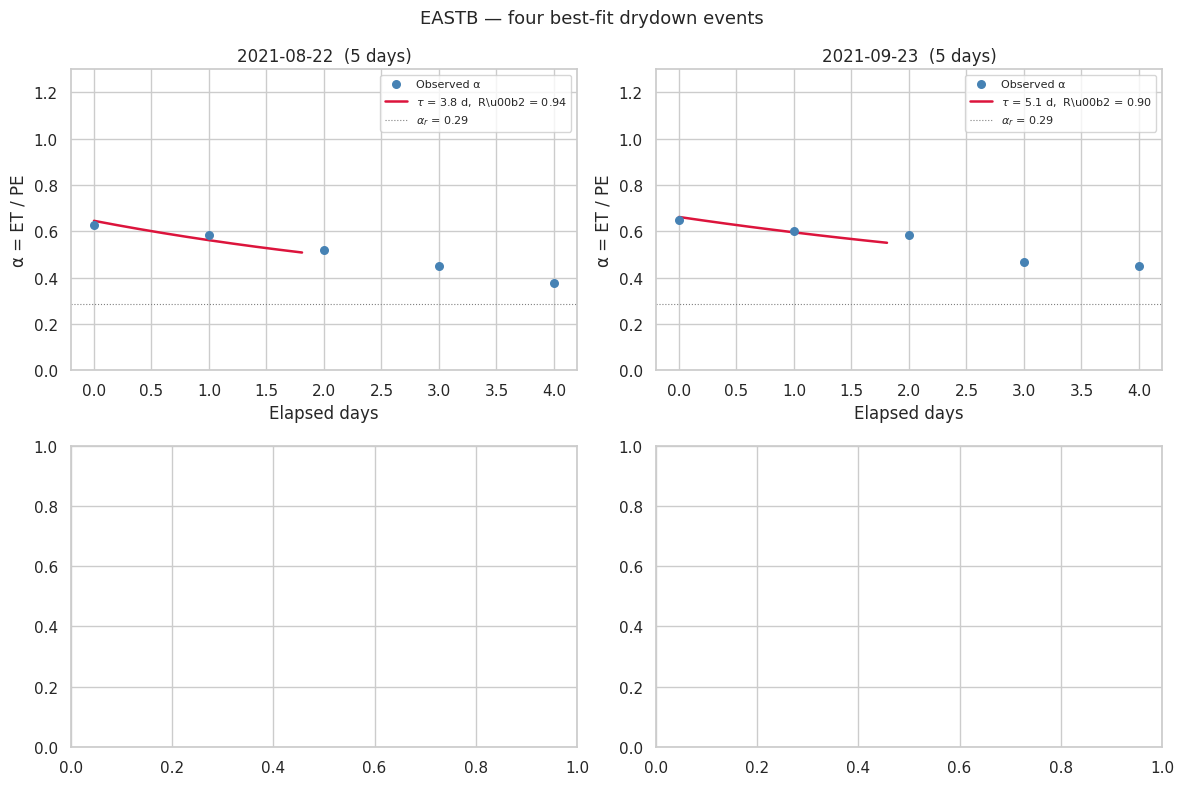

In [26]:
top4 = fits_good.nlargest(4, 'R2').reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
t_fine = np.linspace(0, 40, 200)

for idx, row in top4.iterrows():
    grp = events[events['group_no'] == row['group_no']]
    t   = grp['elapsed'].values.astype(float)
    y   = grp['alpha'].values

    y_fit = exp_decay(t_fine[:int(row['duration'])+5],
                      row['a'], row['tau'], alpha_r)

    ax = axes[idx]
    ax.scatter(t, y, color='steelblue', s=30, zorder=3, label='Observed \u03b1')
    ax.plot(t_fine[:len(y_fit)], y_fit, color='crimson', lw=1.8,
            label=fr'$\tau$ = {row["tau"]:.1f} d,  R\u00b2 = {row["R2"]:.2f}')
    ax.axhline(alpha_r, color='grey', lw=0.8, ls=':', label=fr'$\alpha_r$ = {alpha_r:.2f}')
    ax.set_xlabel('Elapsed days')
    ax.set_ylabel('\u03b1 = ET / PE')
    ax.set_ylim(0, 1.3)
    ax.set_title(f"{row['start_date'].date()}  ({int(row['duration'])} days)")
    ax.legend(fontsize=8)

fig.suptitle(f'{SITE} \u2014 four best-fit drydown events', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Drydown parameter distributions at EASTB

\u03c4 and R\u00b2 distributions give us the typical drydown timescale and how well the exponential model describes it.

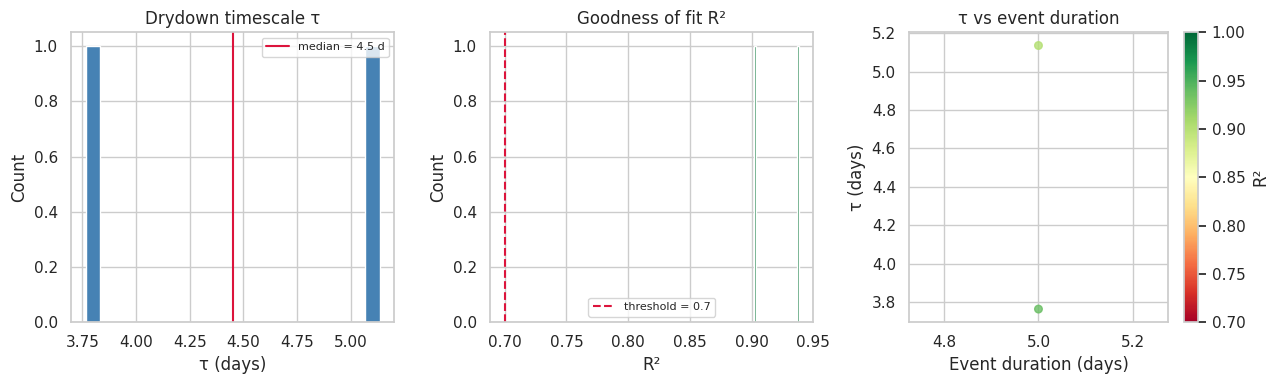


EASTB — drydown summary (R² ≥ 0.7)
        tau    R2  duration  PE_sum
count  2.00  2.00       2.0    2.00
mean   4.45  0.92       5.0    8.48
std    0.97  0.03       0.0    1.72
min    3.76  0.90       5.0    7.27
25%    4.11  0.91       5.0    7.87
50%    4.45  0.92       5.0    8.48
75%    4.79  0.93       5.0    9.09
max    5.14  0.94       5.0    9.70


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# tau distribution
axes[0].hist(fits_good['tau'].clip(upper=80), bins=20,
             color='steelblue', edgecolor='white')
axes[0].axvline(fits_good['tau'].median(), color='crimson', lw=1.5,
                label=f"median = {fits_good['tau'].median():.1f} d")
axes[0].set_xlabel('\u03c4 (days)')
axes[0].set_ylabel('Count')
axes[0].set_title('Drydown timescale \u03c4')
axes[0].legend(fontsize=8)

# R2 distribution
axes[1].hist(fits['R2'].dropna(), bins=25,
             color='seagreen', edgecolor='white')
axes[1].axvline(R2_THRESHOLD, color='crimson', lw=1.5, ls='--',
                label=f'threshold = {R2_THRESHOLD}')
axes[1].set_xlabel('R\u00b2')
axes[1].set_ylabel('Count')
axes[1].set_title('Goodness of fit R\u00b2')
axes[1].legend(fontsize=8)

# tau vs duration scatter
axes[2].scatter(fits_good['duration'], fits_good['tau'],
                c=fits_good['R2'], cmap='RdYlGn', vmin=0.7, vmax=1.0,
                s=30, alpha=0.8)
axes[2].set_xlabel('Event duration (days)')
axes[2].set_ylabel('\u03c4 (days)')
axes[2].set_title('\u03c4 vs event duration')
sm = plt.cm.ScalarMappable(cmap='RdYlGn',
                            norm=plt.Normalize(vmin=0.7, vmax=1.0))
sm.set_array([])
plt.colorbar(sm, ax=axes[2], label='R\u00b2')

plt.tight_layout()
plt.show()

print(f"\n{SITE} \u2014 drydown summary (R\u00b2 \u2265 {R2_THRESHOLD})")
print(fits_good[['tau','R2','duration','PE_sum']].describe().round(2))

---
## 7. Seasonal and interannual variation in \u03c4

**Teuling et al. (2006)** showed that drydown timescale varies with season: summer drydowns are faster (higher VPD, stronger atmospheric demand) than spring ones. Here we test that at EASTB.

/tmp/ipykernel_2743294/314547497.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fits_good[fits_good['tau'] < 80],


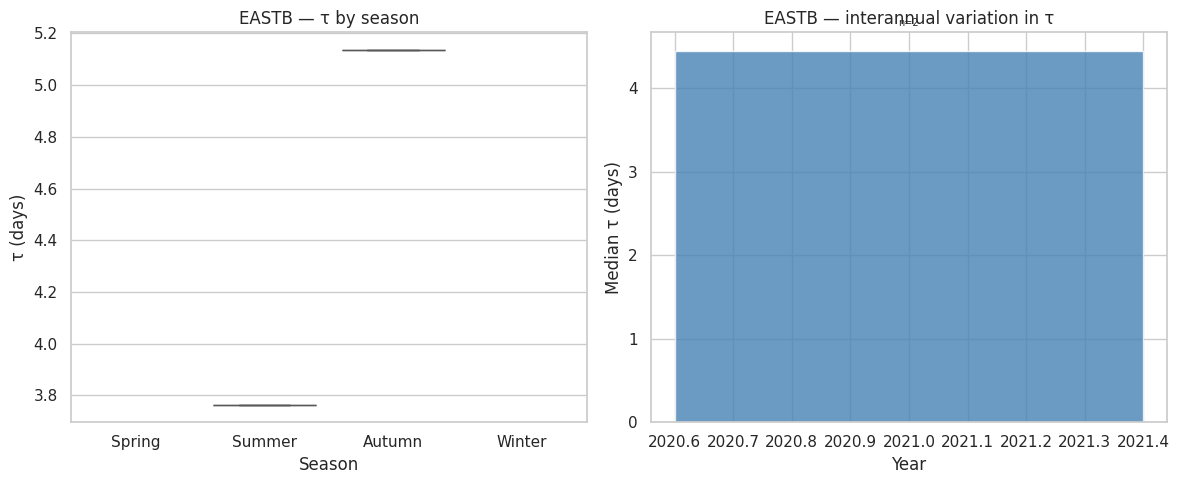

In [28]:
def month_to_season(m):
    if m in [12, 1, 2]: return 'Winter'
    if m in [3, 4, 5]:  return 'Spring'
    if m in [6, 7, 8]:  return 'Summer'
    return 'Autumn'

fits_good = fits_good.copy()
fits_good['month']  = pd.DatetimeIndex(fits_good['start_date']).month
fits_good['season'] = fits_good['month'].map(month_to_season)
fits_good['year']   = pd.DatetimeIndex(fits_good['start_date']).year

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# tau by season
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_palette = {'Spring': '#66c2a5', 'Summer': '#fc8d62',
                  'Autumn': '#8da0cb', 'Winter': '#e78ac3'}
sns.boxplot(data=fits_good[fits_good['tau'] < 80],
            x='season', y='tau', order=season_order,
            palette=season_palette, ax=axes[0])
axes[0].set_xlabel('Season')
axes[0].set_ylabel('\u03c4 (days)')
axes[0].set_title(f'{SITE} \u2014 \u03c4 by season')

# tau by year
yearly = (fits_good.groupby('year')['tau']
          .agg(['median','count'])
          .reset_index())
axes[1].bar(yearly['year'], yearly['median'], color='steelblue', alpha=0.8)
for _, r in yearly.iterrows():
    axes[1].text(r['year'], r['median'] + 0.3, f"n={int(r['count'])}",
                 ha='center', fontsize=7)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median \u03c4 (days)')
axes[1].set_title(f'{SITE} \u2014 interannual variation in \u03c4')

plt.tight_layout()
plt.show()

---
## 8. \u03c4 vs atmospheric demand (PE_sum)

**Seneviratne et al. (2010)** note that higher atmospheric demand should shorten drydown \u2014 more PE means water is depleted faster, reducing \u03c4. We test this relationship at EASTB.

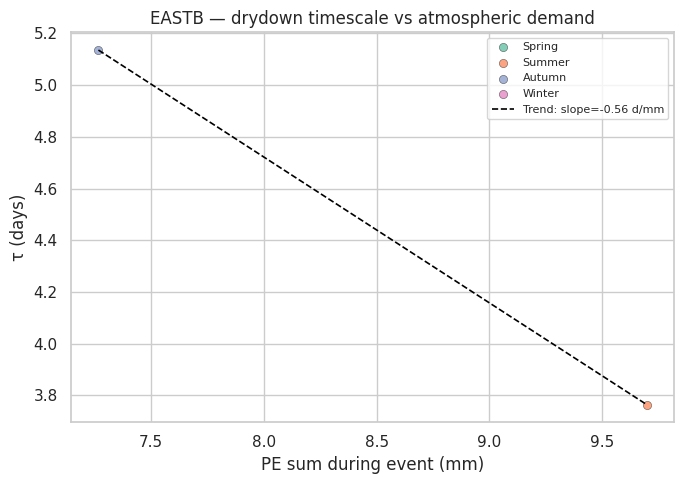

In [29]:
plot_df = fits_good[fits_good['tau'] < 80].copy()
season_colors = plot_df['season'].map(season_palette)

fig, ax = plt.subplots(figsize=(7, 5))
for season in season_order:
    s = plot_df[plot_df['season'] == season]
    ax.scatter(s['PE_sum'], s['tau'],
               color=season_palette[season],
               s=35, alpha=0.8, label=season, edgecolors='k', linewidths=0.3)

# Linear regression line
mask = plot_df[['PE_sum','tau']].notna().all(axis=1)
x, y = plot_df.loc[mask, 'PE_sum'].values, plot_df.loc[mask, 'tau'].values
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m*x_line + b, 'k--', lw=1.2,
        label=f'Trend: slope={m:.2f} d/mm')

ax.set_xlabel('PE sum during event (mm)')
ax.set_ylabel('\u03c4 (days)')
ax.set_title(f'{SITE} \u2014 drydown timescale vs atmospheric demand')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 9. Cross-site comparison — three contrasting land covers

We repeat the analysis for two more sites to contrast τ across land-cover types.
Following **McColl et al. (2017)**, we expect deeper-rooted or more drought-tolerant vegetation to show larger τ.

| Site | Land cover | Hypothesis |
|------|------------|------------|
| EASTB | Improved grassland | Shallow-rooted; moderate τ |
| MORLY | Arable & horticulture | Annual crops; small τ, rapid stress |
| MOORH | Acid grassland | Upland peat; larger water storage, larger τ |

In [30]:
COMPARISON_SITES = {
    'EASTB': 'Improved grassland',
    'MORLY': 'Arable',
    'MOORH': 'Acid grassland (upland peat)',
}

site_fits = {}

for sid, lc in COMPARISON_SITES.items():
    try:
        hh_s     = load_site(sid)
        daily_s  = to_daily(hh_s)
        events_s, n = detect_drydown_events(daily_s)
        alpha_r_s = float(daily_s['alpha'].quantile(0.02))

        rows = []
        for gn, grp in events_s.groupby('group_no'):
            t = grp['elapsed'].values.astype(float)
            y = grp['alpha'].values
            fit = fit_event(t, y, alpha_r_s)
            fit.update({
                'group_no':   gn,
                'start_date': grp.index[0],
                'duration':   len(grp),
                'PE_sum':     grp['PE_sum'].sum(),
            })
            rows.append(fit)

        site_df = pd.DataFrame(rows)
        site_df = site_df[site_df['R2'] >= R2_THRESHOLD].copy()
        site_df['SITE_ID'] = sid
        site_df['LAND_COVER'] = lc
        site_df['alpha_r'] = alpha_r_s
        site_fits[sid] = site_df
        print(f"{sid} ({lc}): {n} events detected, {len(site_df)} retained")
    except Exception as e:
        print(f"{sid}: ERROR \u2014 {e}")

all_fits = pd.concat(site_fits.values(), ignore_index=True)

EASTB (Improved grassland): 2 events detected, 2 retained
MORLY (Arable): 7 events detected, 7 retained
MOORH (Acid grassland (upland peat)): 5 events detected, 5 retained


/tmp/ipykernel_2743294/1381667801.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=all_fits[all_fits['tau'] < 80],
/tmp/ipykernel_2743294/1381667801.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(tick_labels, fontsize=8)


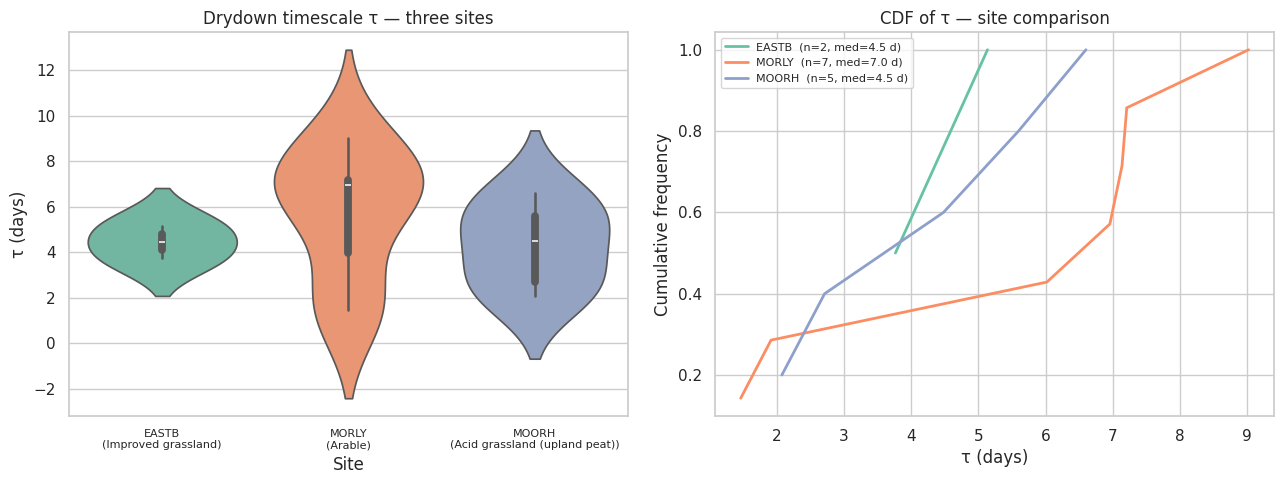

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violin plot of tau
sns.violinplot(data=all_fits[all_fits['tau'] < 80],
               x='SITE_ID', y='tau',
               order=list(COMPARISON_SITES),
               palette='Set2', inner='box', ax=axes[0])
axes[0].set_xlabel('Site')
axes[0].set_ylabel('\u03c4 (days)')
axes[0].set_title('Drydown timescale \u03c4 \u2014 three sites')
tick_labels = [f"{sid}\n({COMPARISON_SITES[sid]})" for sid in COMPARISON_SITES]
axes[0].set_xticklabels(tick_labels, fontsize=8)

# Cumulative distribution of tau per site
site_colors = {'EASTB': '#66c2a5', 'MORLY': '#fc8d62', 'MOORH': '#8da0cb'}
for sid in COMPARISON_SITES:
    tau_vals = all_fits.loc[
        (all_fits['SITE_ID'] == sid) & (all_fits['tau'] < 80), 'tau'
    ].sort_values()
    cdf = np.arange(1, len(tau_vals)+1) / len(tau_vals)
    axes[1].plot(tau_vals, cdf, lw=2, color=site_colors[sid],
                 label=f"{sid}  (n={len(tau_vals)}, "
                       f"med={tau_vals.median():.1f} d)")

axes[1].set_xlabel('\u03c4 (days)')
axes[1].set_ylabel('Cumulative frequency')
axes[1].set_title('CDF of \u03c4 \u2014 site comparison')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 10. EF–soil moisture relationship: α as proxy

Following **Fu et al. (2022)** (*Sci. Adv.*, doi:10.1126/sciadv.abq7827, Figure 1b), we fit a piecewise linear model relating evaporative fraction (EF) to a soil moisture proxy. Here we use **α = ET/PE** as that proxy — it is computed from the flux data alone and tracks the transition from energy-limited to water-limited conditions:

$$\text{EF}(\alpha) = \begin{cases} \text{EF}_{\max} & \text{if } \alpha \geq \alpha_\text{crit} \\ \text{EF}_{\max} + S\,(\alpha - \alpha_\text{crit}) & \text{if } \alpha < \alpha_\text{crit} \end{cases}$$

This approach requires no additional sensor data and can therefore be applied at any eddy covariance site in the network. Section 10 repeats the analysis using actual volumetric water content (VWC) from the EASTB TDT sensors for comparison.

EF_max   = 0.899
α_crit   = 0.717
Slope S  = 0.607  (EF per unit α)
R²       = 0.098  (n = 696 daily observations)


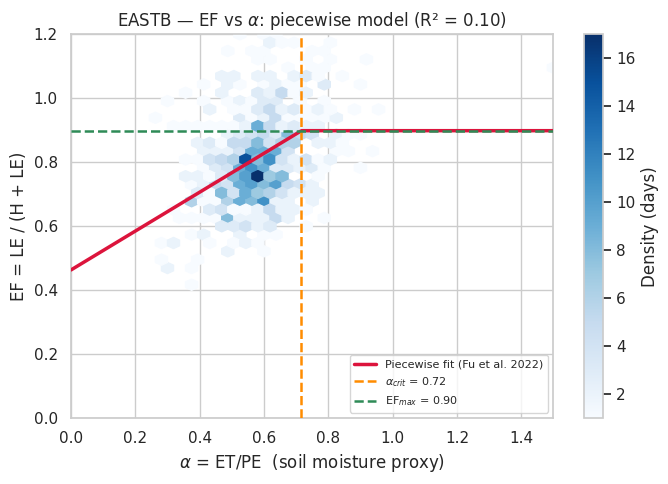

In [32]:
def fit_ef_alpha(daily_df):
    """
    Fit piecewise EF–alpha model (Fu et al. 2022, Sci. Adv.).
    Grid search over alpha_crit; OLS for EF_max and slope at each candidate.
    """
    df = daily_df[['EF', 'alpha']].dropna()
    df = df[(df['EF'] > 0) & (df['EF'] < 1.2) &
            (df['alpha'] > 0) & (df['alpha'] <= 1.5)]

    a  = df['alpha'].values
    ef = df['EF'].values

    candidates = np.percentile(a, np.linspace(10, 90, 81))
    best = {'r2': -np.inf}
    for ac in candidates:
        wet, dry = a >= ac, a < ac
        if wet.sum() < 10 or dry.sum() < 10:
            continue
        ef_max = np.mean(ef[wet])
        x_dry  = a[dry] - ac
        y_dry  = ef[dry] - ef_max
        slope  = np.dot(x_dry, y_dry) / np.dot(x_dry, x_dry)
        y_pred = np.where(wet, ef_max, ef_max + slope * (a - ac))
        ss_res = np.sum((ef - y_pred) ** 2)
        ss_tot = np.sum((ef - ef.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        if r2 > best['r2']:
            best = {'r2': r2, 'ef_max': ef_max, 'alpha_crit': ac,
                    'slope': slope, 'n': len(df)}
    return best, df


result_ef, ef_df = fit_ef_alpha(daily)
ef_max_fit  = result_ef['ef_max']
alpha_crit  = result_ef['alpha_crit']
slope_fit   = result_ef['slope']
r2_ef       = result_ef['r2']

print(f"EF_max   = {ef_max_fit:.3f}")
print(f"α_crit   = {alpha_crit:.3f}")
print(f"Slope S  = {slope_fit:.3f}  (EF per unit α)")
print(f"R²       = {r2_ef:.3f}  (n = {result_ef['n']} daily observations)")

# ── Plot ──────────────────────────────────────────────────────────────────────
alpha_x = np.linspace(0, 1.5, 300)
ef_hat  = np.where(alpha_x >= alpha_crit,
                   ef_max_fit,
                   ef_max_fit + slope_fit * (alpha_x - alpha_crit))

fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(ef_df['alpha'], ef_df['EF'], gridsize=40, cmap='Blues',
               extent=[0, 1.5, 0, 1.2], mincnt=1)
plt.colorbar(hb, ax=ax, label='Density (days)')

ax.plot(alpha_x, ef_hat, color='crimson', lw=2.5, zorder=5,
        label='Piecewise fit (Fu et al. 2022)')
ax.axvline(alpha_crit, color='darkorange', lw=1.8, ls='--', zorder=6,
           label=fr'$\alpha_{{crit}}$ = {alpha_crit:.2f}')
ax.axhline(ef_max_fit, color='seagreen', lw=1.8, ls='--', zorder=6,
           label=f'EF$_{{max}}$ = {ef_max_fit:.2f}')

ax.set_xlabel(r'$\alpha$ = ET/PE  (soil moisture proxy)')
ax.set_ylabel('EF = LE / (H + LE)')
ax.set_xlim(0, 1.5)
ax.set_ylim(0, 1.2)
ax.set_title(fr'{SITE} — EF vs $\alpha$: piecewise model (R² = {r2_ef:.2f})')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

---
## 11. EF–soil moisture relationship: actual VWC

This section repeats the piecewise model from Section 9, replacing α with measured soil moisture (θ, % VWC) from the EASTB TDT capacitance sensors. Comparing the two fits allows assessment of how well α serves as a soil moisture proxy at this site.

Soil moisture is taken from `cosmos-uk_eastb_hydrosoil_sh_2014-2024.csv`, which includes two TDT sensors (TDT1, TDT2). Daily mean VWC is computed from whichever sensors are available, requiring ≥ 8 valid half-hourly readings per day. The daily EF from the flux data (Section 1) is joined on date.

$$\text{EF}(\theta) = \begin{cases} \text{EF}_{\max} & \text{if } \theta \geq \theta_\text{crit} \\ \text{EF}_{\max} + S\,(\theta - \theta_\text{crit}) & \text{if } \theta < \theta_\text{crit} \end{cases}$$

| Parameter | Meaning |
|-----------|---------|
| **EF_max** | Maximum EF under non-water-stressed conditions (wet soil plateau) |
| **θ_crit** | Critical VWC below which water limitation begins to suppress ET |
| **S** | Slope of EF decline per % VWC decrease below θ_crit (S > 0) |

Daily VWC records: 3,148  (6.4–47.9 %, mean 30.1 %)
Matched EF–VWC pairs: 738

EF_max    = 0.841
θ_crit    = 24.1 % VWC
Slope S   = 0.0090  (EF per % VWC)
R²        = 0.089  (n = 738 daily observations)


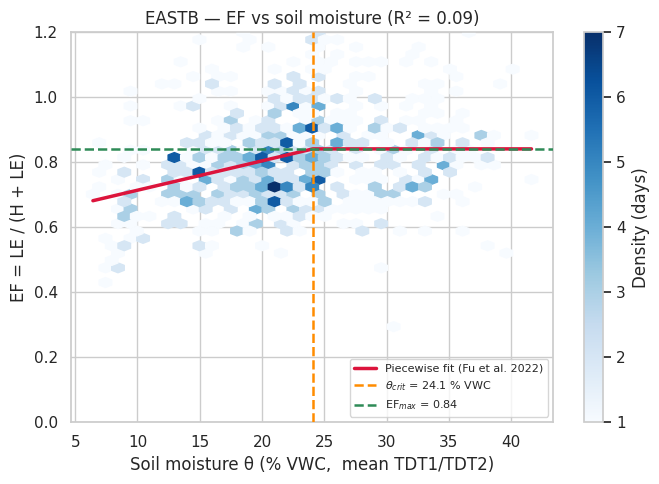

In [33]:
# ── Load and aggregate soil moisture ─────────────────────────────────────────
SM_PATH = 'data_sm/cosmos-uk_eastb_hydrosoil_sh_2014-2024.csv'

sm_hh = pd.read_csv(SM_PATH, na_values=-9999, parse_dates=['DATE_TIME'],
                    usecols=['DATE_TIME', 'TDT1_VWC', 'TDT2_VWC'])
sm_hh['DATE_TIME'] = pd.to_datetime(sm_hh['DATE_TIME'], utc=True)
sm_hh = sm_hh.set_index('DATE_TIME').sort_index()

# Mean VWC across both sensors (handle partial availability)
sm_hh['VWC'] = sm_hh[['TDT1_VWC', 'TDT2_VWC']].mean(axis=1)
sm_hh = sm_hh[sm_hh['VWC'].between(3, 70)]  # remove physically implausible values

# Daily mean: require >= 8 valid half-hourly readings
daily_vwc = (sm_hh['VWC']
             .resample('D')
             .agg(lambda x: x.mean() if x.notna().sum() >= 8 else float('nan')))

print(f"Daily VWC records: {daily_vwc.notna().sum():,}  "
      f"({daily_vwc.min():.1f}–{daily_vwc.max():.1f} %, "
      f"mean {daily_vwc.mean():.1f} %)")

# ── Merge EF and VWC on date ──────────────────────────────────────────────────
# Normalise daily index to UTC midnight for the join
daily_utc = daily.copy()
daily_utc.index = daily_utc.index.normalize()
daily_vwc.index = daily_vwc.index.normalize()

ef_vwc = (daily_utc[['EF']]
          .join(daily_vwc.rename('VWC'), how='inner')
          .dropna())
ef_vwc = ef_vwc[(ef_vwc['EF'] > 0) & (ef_vwc['EF'] < 1.2)]
print(f"Matched EF–VWC pairs: {len(ef_vwc)}")

# ── Piecewise linear fit (Fu et al. 2022) ────────────────────────────────────
def fit_piecewise(sm_vals, ef_vals):
    """Grid search over θ_crit; OLS for EF_max and slope at each candidate."""
    candidates = np.percentile(sm_vals, np.linspace(10, 90, 81))
    best = {'r2': -np.inf}
    for tc in candidates:
        wet, dry = sm_vals >= tc, sm_vals < tc
        if wet.sum() < 10 or dry.sum() < 10:
            continue
        ef_max = np.mean(ef_vals[wet])
        x_dry  = sm_vals[dry] - tc
        y_dry  = ef_vals[dry] - ef_max
        slope  = np.dot(x_dry, y_dry) / np.dot(x_dry, x_dry)
        y_pred = np.where(wet, ef_max, ef_max + slope * (sm_vals - tc))
        ss_res = np.sum((ef_vals - y_pred) ** 2)
        ss_tot = np.sum((ef_vals - ef_vals.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        if r2 > best['r2']:
            best = {'r2': r2, 'ef_max': ef_max, 'theta_crit': tc,
                    'slope': slope, 'n': len(ef_vals)}
    return best

result_sm = fit_piecewise(ef_vwc['VWC'].values, ef_vwc['EF'].values)
ef_max_sm   = result_sm['ef_max']
theta_crit  = result_sm['theta_crit']
slope_sm    = result_sm['slope']
r2_sm       = result_sm['r2']

print(f"\nEF_max    = {ef_max_sm:.3f}")
print(f"θ_crit    = {theta_crit:.1f} % VWC")
print(f"Slope S   = {slope_sm:.4f}  (EF per % VWC)")
print(f"R²        = {r2_sm:.3f}  (n = {result_sm['n']} daily observations)")

# ── Plot ──────────────────────────────────────────────────────────────────────
vwc_x  = np.linspace(ef_vwc['VWC'].min(), ef_vwc['VWC'].max(), 300)
ef_hat = np.where(vwc_x >= theta_crit,
                  ef_max_sm,
                  ef_max_sm + slope_sm * (vwc_x - theta_crit))

fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(ef_vwc['VWC'], ef_vwc['EF'], gridsize=35, cmap='Blues',
               mincnt=1)
plt.colorbar(hb, ax=ax, label='Density (days)')

ax.plot(vwc_x, ef_hat, color='crimson', lw=2.5, zorder=5,
        label='Piecewise fit (Fu et al. 2022)')
ax.axvline(theta_crit, color='darkorange', lw=1.8, ls='--', zorder=6,
           label=fr'$\theta_{{crit}}$ = {theta_crit:.1f} % VWC')
ax.axhline(ef_max_sm, color='seagreen', lw=1.8, ls='--', zorder=6,
           label=f'EF$_{{max}}$ = {ef_max_sm:.2f}')

ax.set_xlabel('Soil moisture θ (% VWC,  mean TDT1/TDT2)')
ax.set_ylabel('EF = LE / (H + LE)')
ax.set_ylim(0, 1.2)
ax.set_title(fr'{SITE} — EF vs soil moisture (R² = {r2_sm:.2f})')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

## Conclusions

| Metric | Description | Key finding |
|--------|-------------|-------------|
| **α = ET/PE** | Evaporative stress factor | Declines exponentially during dry spells |
| **τ** | Drydown timescale (days) | Varies by site, season, and land cover |
| **α_r** | Residual stress (site minimum α) | Reflects bare-soil evaporation floor |
| **R²** | Fit quality | Exponential model fits most events well |

**Physical interpretation of τ** (after McColl et al. 2017):
$$\tau = \frac{W}{ET_{max}} \approx \frac{\text{plant-available water depth}}{\text{max ET rate}}$$

A site with deeper roots or larger plant-available water shows larger τ, meaning it sustains near-potential ET for longer before soil water stress becomes apparent. The cross-site comparison demonstrates that land cover is a primary control on τ at COSMOS-UK sites, with arable sites (MORLY) showing faster drydowns than upland peaty grassland (MOORH).

### Next steps
- Scale to all 45 COSMOS-UK sites to map τ across UK land covers
- Correlate τ with soil physical properties (bulk density, SOC) from site metadata
- Compare ET-derived τ with soil-moisture-derived τ from COSMOS probes

*Funding: The COSMOS-UK network is supported by NERC through the UKCEH National Capability Programme (NE/Y006208/1). Data are available from the NERC Environmental Information Data Centre: [https://doi.org/10.5285/9bde4f25-9e3c-4d39-864b-f4a88ae32782](https://doi.org/10.5285/9bde4f25-9e3c-4d39-864b-f4a88ae32782).*